# Netflix Movies and TV Shows: Comprehensive Data Analysis

Dalam analisis ini, kita akan melakukan eksplorasi mendalam terhadap dataset Netflix. Tujuannya adalah untuk memahami pola, tren, dan distribusi konten yang tersedia di platform Netflix.

## 1. Import Libraries

Langkah pertama adalah mengimpor semua library yang diperlukan untuk manipulasi data dan visualisasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

## 2. Load Dataset

Memuat dataset dari folder `Dataset` yang berada di direktori utama proyek.

In [2]:
df = pd.read_csv('../Dataset/netflix_titles.csv')
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Data Overview

Memeriksa dimensi dataset, tipe data setiap kolom, serta mendeteksi adanya nilai yang hilang (missing values).

In [3]:
display(df.shape)
display(df.info())
display(df.isnull().sum())

(8807, 12)

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


None

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## 4. Data Cleaning

Berdasarkan observasi, terdapat beberapa kolom dengan nilai yang hilang. Selain itu, terdapat anomali pada kolom `rating` di mana durasi film (misalnya '74 min') tercatat di kolom rating untuk beberapa entri. Kita akan membersihkan data ini.

In [4]:
anomalies = df[df['rating'].str.contains('min', na=False)]
for index in anomalies.index:
    df.loc[index, 'duration'] = df.loc[index, 'rating']
    df.loc[index, 'rating'] = np.nan

df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

## 5. Exploratory Data Analysis (EDA)

### 5.1. Distribusi Tipe Konten: Movies vs TV Shows

Melihat proporsi antara film dan serial TV di Netflix.

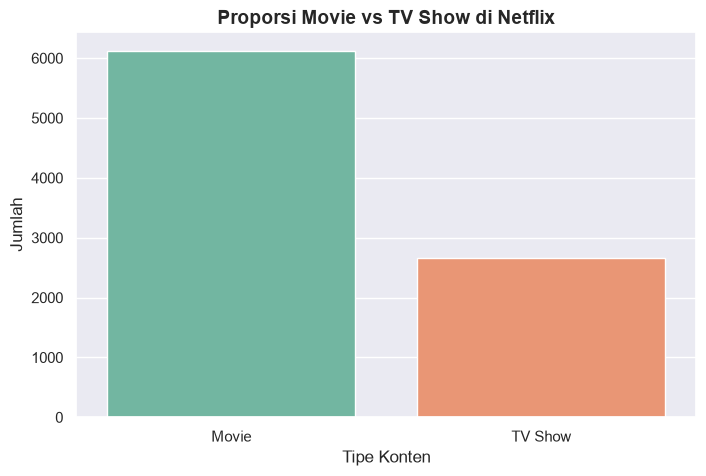

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='type', palette='Set2')
plt.title('Proporsi Movie vs TV Show di Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Konten')
plt.ylabel('Jumlah')
plt.show()

### 5.2. Top 10 Negara Produsen Konten Terbanyak

Mengetahui negara mana yang paling banyak memproduksi konten di Netflix.

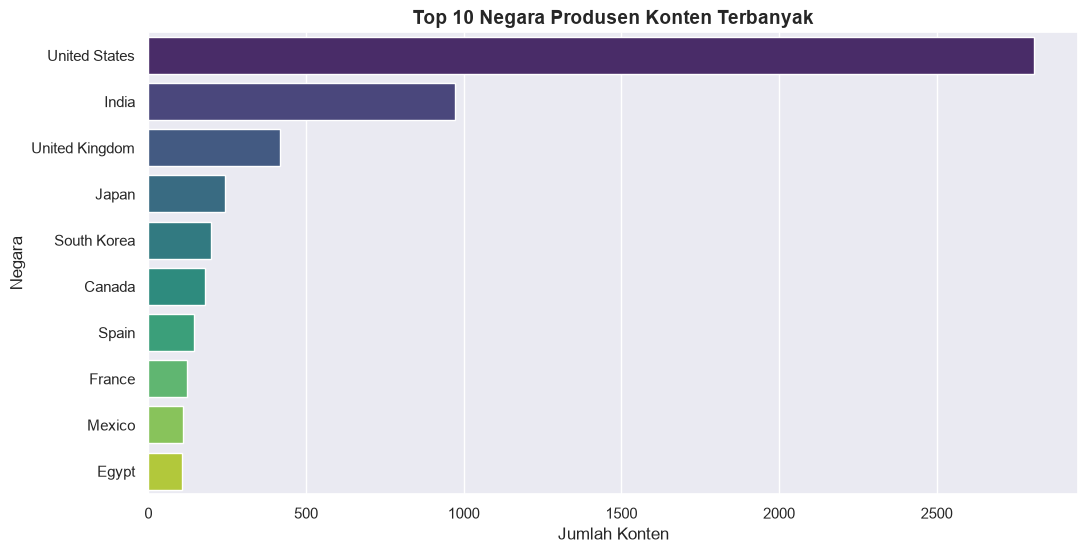

In [6]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y=top_countries.index, x=top_countries.values, palette='viridis')
plt.title('Top 10 Negara Produsen Konten Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Konten')
plt.ylabel('Negara')
plt.show()

### 5.3. Tren Penambahan Konten dari Tahun ke Tahun

Menganalisis bagaimana pertumbuhan konten Netflix dari tahun ke tahun berdasarkan tanggal ditambahkan.

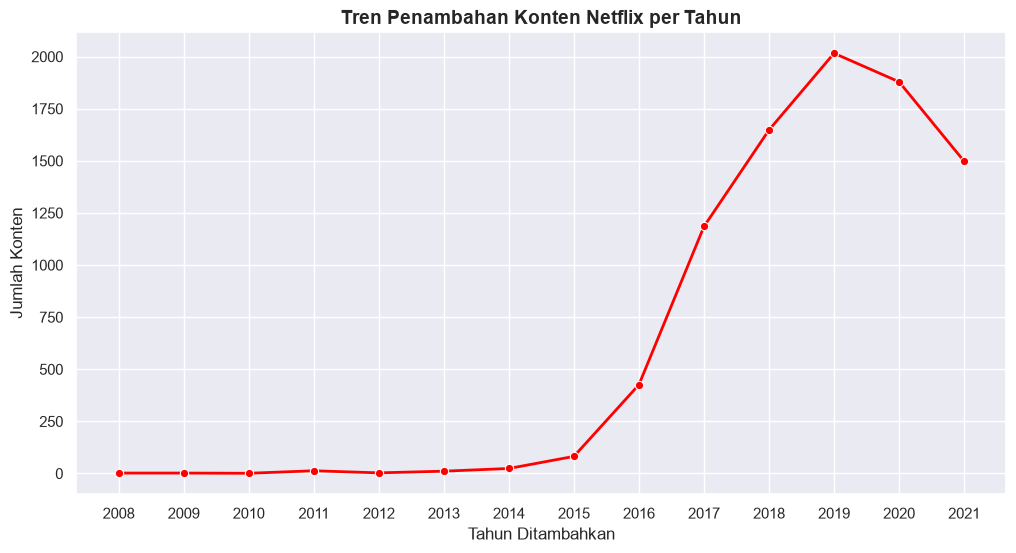

In [7]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='red', linewidth=2)
plt.title('Tren Penambahan Konten Netflix per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun Ditambahkan')
plt.ylabel('Jumlah Konten')
plt.xticks(year_counts.index)
plt.show()

### 5.4. Distribusi Rating Usia

Memahami target audiens Netflix melalui distribusi rating usia pada konten.

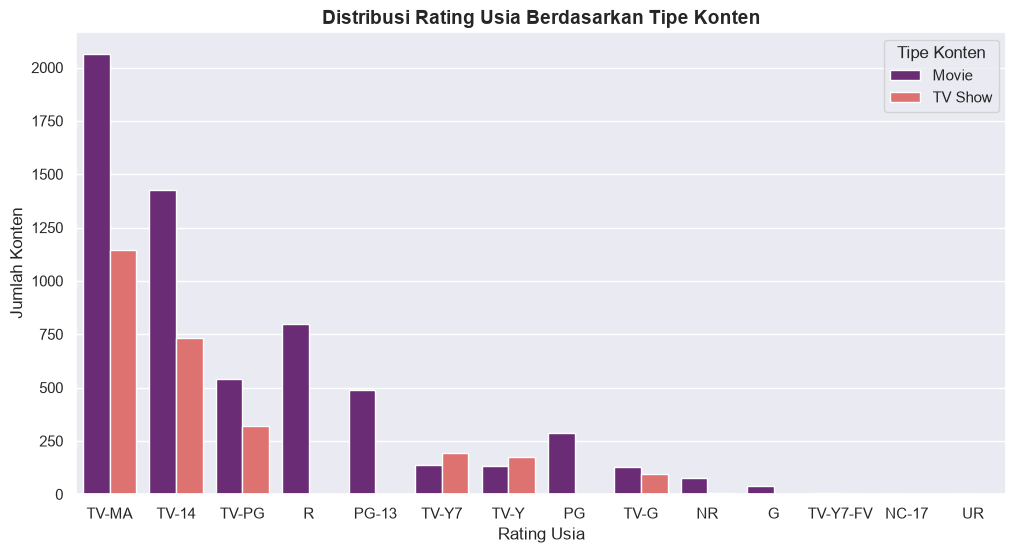

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette='magma')
plt.title('Distribusi Rating Usia Berdasarkan Tipe Konten', fontsize=14, fontweight='bold')
plt.xlabel('Rating Usia')
plt.ylabel('Jumlah Konten')
plt.legend(title='Tipe Konten')
plt.show()

## 6. Key Insights (Kesimpulan)

1. **Dominasi Film (Movies)**: Netflix memiliki lebih banyak koleksi Film dibandingkan dengan Serial TV, dengan rasio sekitar 70% berbanding 30%.
2. **Amerika Serikat sebagai Pusat Produksi**: Mayoritas konten di Netflix diproduksi oleh Amerika Serikat, disusul oleh India dan Inggris.
3. **Fokus pada Konten Dewasa**: Rating usia `TV-MA` (Mature Audiences) merupakan kategori terbanyak. Hal ini menunjukkan bahwa target audiens utama Netflix adalah orang dewasa.
4. **Pertumbuhan Eksponensial**: Terjadi lonjakan penambahan konten secara masif mulai dari tahun 2016 hingga mencapai puncaknya pada periode 2019-2020.